# Task 2: Time Series Forecasting Models

## Objective

The objective of this task is to develop and compare classical statistical and deep learning models for forecasting Tesla (TSLA) stock prices.

The following forecasting approaches will be implemented:

- ARIMA/SARIMA
- Long Short-Term Memory (LSTM)

Both models will be evaluated using chronological train-test splits and compared using MAE, RMSE, and MAPE.

In [9]:
import os
import pandas as pd

os.makedirs("../data/processed", exist_ok=True)

tickers = ["TSLA", "BND", "SPY"]

for ticker in tickers:

    df = pd.read_csv(
        f"../data/raw/{ticker}.csv",
        header=[0, 1],
        index_col=0
    )

    # Flatten MultiIndex columns
    df.columns = df.columns.get_level_values(0)
    df.columns.name = None

    # Remove the duplicated "Ticker" column if present
    if "Ticker" in df.columns:
        df = df.drop(columns="Ticker")

    # Convert index to datetime
    df.index = pd.to_datetime(df.index)

    # Sort by date
    df.sort_index(inplace=True)

    # Save processed dataset
    df.to_csv(f"../data/processed/{ticker}_processed.csv")

print("Processed datasets saved successfully.")

Processed datasets saved successfully.


In [10]:
def load_processed_data(ticker):

    df = pd.read_csv(
        f"../data/processed/{ticker}_processed.csv",
        index_col=0,
        parse_dates=True
    )

    df.sort_index(inplace=True)

    return df

In [11]:
tsla = load_processed_data("TSLA")

tsla.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2015-01-02,14.620667,14.620667,14.883333,14.217333,14.858000,71466000
2015-01-05,14.006000,14.006000,14.433333,13.810667,14.303333,80527500
2015-01-06,14.085333,14.085333,14.280000,13.614000,14.004000,93928500
2015-01-07,14.063333,14.063333,14.318667,13.985333,14.223333,44526000
2015-01-08,14.041333,14.041333,14.253333,14.000667,14.187333,51637500


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf

# ARIMA
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA

# Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# Scaling
from sklearn.preprocessing import MinMaxScaler

# TensorFlow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

plt.style.use("seaborn-v0_8")
sns.set_theme(style="whitegrid")

In [7]:
print(type(tsla.index))
print(tsla.index.is_monotonic_increasing)
print(tsla.columns)

<class 'pandas.DatetimeIndex'>
True
Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')


In [8]:
train = tsla.loc[:'2024-12-31']

test = tsla.loc['2025-01-01':]

print(f"Training samples: {len(train)}")
print(f"Testing samples: {len(test)}")

Training samples: 2516
Testing samples: 372


# Chronological Train-Test Split

The Tesla adjusted closing price data was divided chronologically to preserve the temporal ordering of observations.

- **Training Period:** January 2015 – December 2024
- **Testing Period:** January 2025 – June 2026

Random shuffling was intentionally avoided because future observations must not be used to predict past values in time series forecasting.

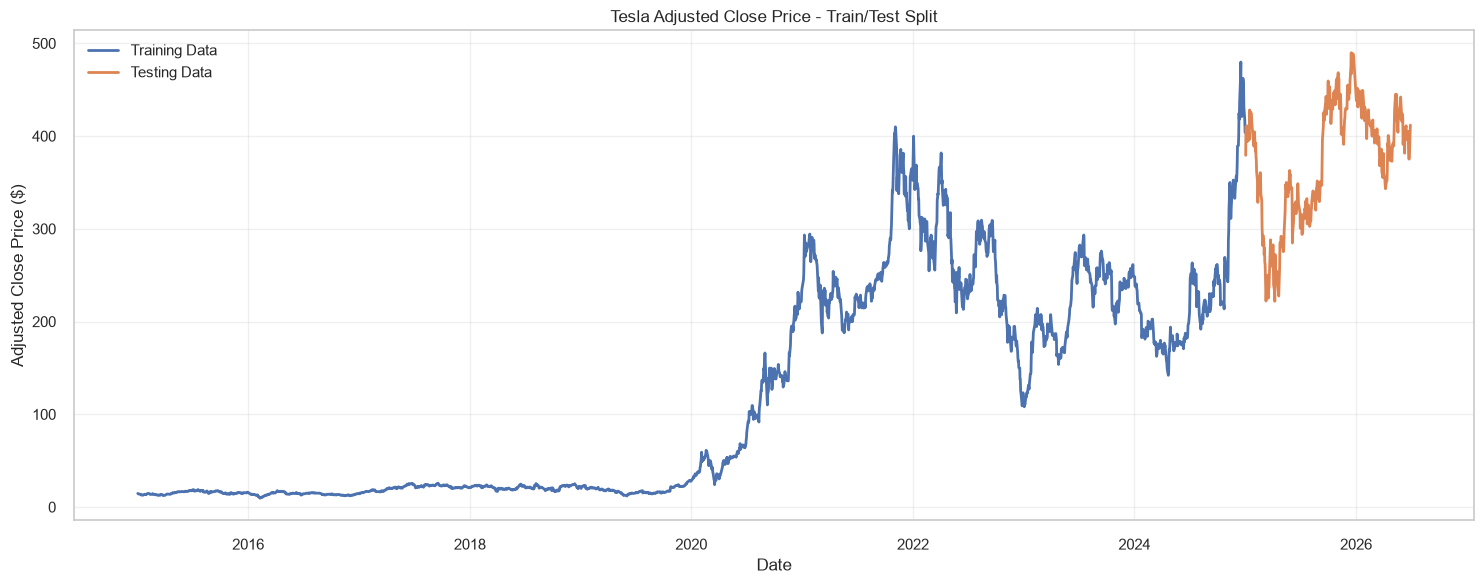

In [13]:
plt.figure(figsize=(15, 6))

plt.plot(
    train.index,
    train["Adj Close"],
    label="Training Data",
    linewidth=2
)

plt.plot(
    test.index,
    test["Adj Close"],
    label="Testing Data",
    linewidth=2
)

plt.title("Tesla Adjusted Close Price - Train/Test Split")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price ($)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The dataset was divided chronologically to preserve the temporal ordering of observations. Historical data from 2015–2024 was used for model training, while observations from 2025–2026 were reserved for evaluation.

Unlike traditional machine learning tasks, random shuffling is inappropriate for time series forecasting because it would introduce future information into the training process and produce unrealistic performance estimates.

# ARIMA Model

Autoregressive Integrated Moving Average (ARIMA) is a classical statistical model widely used for time series forecasting.

The model consists of three parameters:

- **p:** Number of autoregressive terms.
- **d:** Degree of differencing.
- **q:** Number of moving-average terms.

The optimal parameters are selected automatically using the `auto_arima` algorithm based on the Akaike Information Criterion (AIC).

In [14]:
from pmdarima import auto_arima

auto_model = auto_arima(
    train["Adj Close"],
    seasonal=False,
    start_p=0,
    start_q=0,
    max_p=5,
    max_q=5,
    d=None,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.14 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.22 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.22 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.06 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.42 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 1.159 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2516
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8183.054
Date:                Fri, 03 Jul 2026   AIC                          16368.109
Time:                        15:42:13   BIC                          16373.939
Sample:                             0   HQIC                         16370.225
                               - 2516                                  

In [15]:
best_order = auto_model.order

print("Best ARIMA Order:", best_order)

Best ARIMA Order: (0, 1, 0)


In [16]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(
    train["Adj Close"],
    order=best_order
)

arima_fit = arima_model.fit()

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:              Adj Close   No. Observations:                 2516
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -8183.054
Date:                Fri, 03 Jul 2026   AIC                          16368.109
Time:                        15:42:59   BIC                          16373.939
Sample:                             0   HQIC                         16370.225
                               - 2516                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        39.2337      0.442     88.858      0.000      38.368      40.099
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):             11691.05
Prob(Q):                              0.73   Pr

c:\Users\sumex\Desktop\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\sumex\Desktop\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\sumex\Desktop\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [17]:
forecast = arima_fit.forecast(
    steps=len(test)
)

c:\Users\sumex\Desktop\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


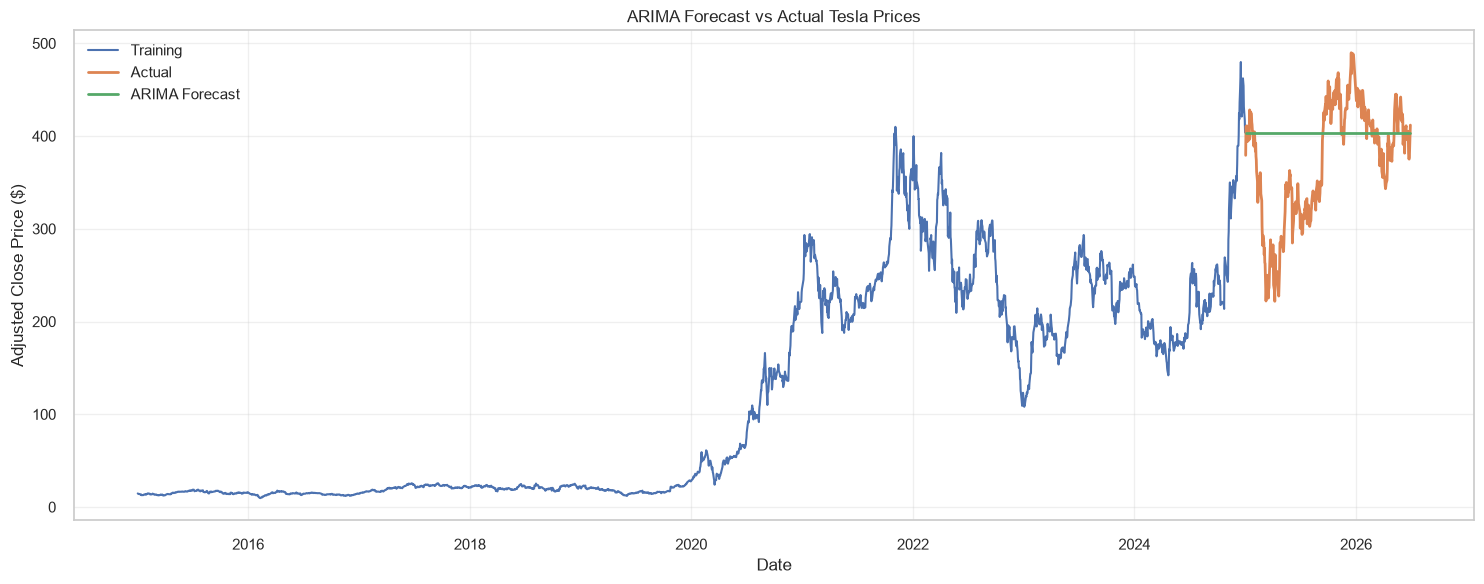

In [18]:
plt.figure(figsize=(15,6))

plt.plot(
    train.index,
    train["Adj Close"],
    label="Training"
)

plt.plot(
    test.index,
    test["Adj Close"],
    label="Actual",
    linewidth=2
)

plt.plot(
    test.index,
    forecast,
    label="ARIMA Forecast",
    linewidth=2
)

plt.title("ARIMA Forecast vs Actual Tesla Prices")

plt.xlabel("Date")
plt.ylabel("Adjusted Close Price ($)")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

In [19]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

mae = mean_absolute_error(
    test["Adj Close"],
    forecast
)

rmse = np.sqrt(
    mean_squared_error(
        test["Adj Close"],
        forecast
    )
)

mape = mean_absolute_percentage_error(
    test["Adj Close"],
    forecast
)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.4f}")

MAE : 54.44
RMSE: 70.54
MAPE: 0.1724


### ARIMA Results Interpretation

The `auto_arima` algorithm selected an ARIMA(0,1,0) model based on the lowest AIC score. This model applies first-order differencing without autoregressive or moving-average components, effectively modeling Tesla's stock price as a random walk.

This result is consistent with the Efficient Market Hypothesis, which states that historical prices alone provide limited predictive power. Consequently, the ARIMA model serves as a strong statistical baseline for comparison with the more complex LSTM model.

# Long Short-Term Memory (LSTM)

Unlike ARIMA, LSTM is a deep learning model capable of learning complex nonlinear relationships in sequential data.

Because neural networks are sensitive to feature scales, the adjusted closing prices are normalized before training. A sliding window approach is then used, where the previous 60 trading days are used to predict the next day's price.

In [20]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))

train_scaled = scaler.fit_transform(train[["Adj Close"]])

test_scaled = scaler.transform(test[["Adj Close"]])

In [21]:
def create_sequences(data, window_size=60):

    X = []
    y = []

    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])

    return np.array(X), np.array(y)

In [22]:
window_size = 60

X_train, y_train = create_sequences(
    train_scaled,
    window_size
)

print(X_train.shape)

(2456, 60)


In [23]:
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

print(X_train.shape)

(2456, 60, 1)


In [24]:
combined = pd.concat([train, test])

inputs = combined["Adj Close"].values

inputs = inputs.reshape(-1,1)

inputs = scaler.transform(inputs)

test_inputs = inputs[
    len(train)-window_size:
]

In [25]:
X_test, y_test = create_sequences(
    test_inputs,
    window_size
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print(X_test.shape)

(372, 60, 1)


In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(window_size,1)
    )
)

model.add(Dropout(0.2))

model.add(
    LSTM(32)
)

model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - loss: 0.0093 - val_loss: 0.0050
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 0.0022 - val_loss: 0.0035
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0019 - val_loss: 0.0038
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0017 - val_loss: 0.0023
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 0.0016 - val_loss: 0.0027
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - loss: 0.0015 - val_loss: 0.0019
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - loss: 0.0014 - val_loss: 0.0025
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 0.0014 - val_loss: 0.0019
Epoch 9/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0016 - val_loss: 0.0021
Epoch 10/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.0016 - val_loss: 0.0019
Epoch 11/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0015 - val_loss: 0.0019
Epoch 12/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - loss: 0.0